# Prediksi Rata-rata Parameter Produksi Bulan Depan — MT-620

Notebook ini memprediksi **rata-rata bulanan** tiap parameter untuk **bulan berikutnya**,
menggunakan **tanggal** sebagai variabel waktu (tren). Pendekatan:

1. Data diagregasi menjadi rata-rata per bulan (meredam noise antar-batch).
2. Dilakukan **EDA** (Exploratory Data Analysis) untuk memahami distribusi data.
3. **Uji Normalitas** (Shapiro-Wilk) dan **Uji Stasioneritas** (ADF) sebagai validasi asumsi.
4. Untuk parameter ber-**tren jelas** (R² tren ≥ 0.30) → dipakai model **tren linear**.
5. Untuk parameter **datar** → prediksi = **rata-rata historis** + interval.
6. Evaluasi model dengan **MAE, RMSE, MAPE** dan **Cross-Validation**.
7. Semua disertai **interval kepercayaan 95%**.

> Catatan: yang diprediksi adalah **rata-rata bulanan**, bukan nilai tiap batch. Tanggal di sini
> berperan sebagai **proksi tren**, bukan penyebab kimiawi langsung.

## 1. Import & Load

In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller
import warnings; warnings.filterwarnings('ignore')

file_path=r"Data_Chemical_2026.04-16-MT620.xlsx"   # sesuaikan path
df=pd.read_excel(file_path)
param=['Transmission','Tin','RI','SG','Acid','Sulfur','Water','Mono','Yellow','EH','Visco','PT']
print('shape awal:',df.shape)

## 2. Bersihkan & Agregasi per Bulan

In [2]:
df=df.drop_duplicates()
df['Tanggal']=pd.to_datetime(df['Tanggal'],errors='coerce')
df=df.dropna(subset=['Tanggal'])
for c in param: df[c]=pd.to_numeric(df[c],errors='coerce')
df=df.dropna(subset=param,how='any').reset_index(drop=True)
df['bulan']=df['Tanggal'].dt.to_period('M')

mon=df.groupby('bulan')[param].mean()
print('jumlah bulan:',len(mon),'| rentang:',mon.index.min(),'-',mon.index.max())
mon.round(3)

jumlah bulan: 12 | rentang: 2025-05 - 2026-04


,Transmission,Tin,RI,SG,Acid,Sulfur,Water,Mono,Yellow,EH,Visco,PT
bulan,,,,,,,,,,,,
2025-05,98.997,19.076,1.509,1.171,1.125,11.995,2.405,23.804,7.990,0.248,60.577,14.494
2025-06,99.081,19.101,1.509,1.170,0.908,11.982,2.606,23.524,7.993,0.194,58.152,13.221
2025-07,99.016,19.080,1.511,1.170,0.987,12.010,2.383,23.659,8.061,0.231,58.321,14.135
2025-08,99.038,19.125,1.511,1.172,0.926,12.003,2.409,23.390,8.180,0.206,57.918,13.527
2025-09,98.993,19.069,1.510,1.171,1.144,11.928,2.378,23.682,8.088,0.240,56.841,14.976
2025-10,98.991,19.054,1.509,1.171,1.179,11.943,2.279,23.665,7.895,0.258,57.213,14.021
2025-11,98.993,19.094,1.510,1.171,1.124,11.904,2.323,23.740,7.905,0.230,57.769,15.118
2025-12,99.013,19.043,1.510,1.170,1.146,11.919,2.240,23.351,7.874,0.253,57.421,14.520
2026-01,98.941,19.031,1.510,1.170,1.241,11.903,2.361,23.640,7.838,0.241,59.040,13.733


## 3. Exploratory Data Analysis (EDA)

Sebelum melakukan prediksi, penting untuk memahami karakteristik data melalui:
- **Statistik deskriptif** (mean, std, min, max, dll.)
- **Distribusi** masing-masing parameter (histogram)
- **Deteksi outlier** (boxplot)
- **Korelasi** antar parameter (heatmap)

> **Referensi:** McKinney, W. (2017). *Python for Data Analysis*, 2nd Ed. O'Reilly.

In [ ]:
# --- 3a. Statistik Deskriptif ---
print("=== Statistik Deskriptif (Data Bulanan) ===")
desc = mon.describe().round(4)
display(desc)

# --- 3b. Histogram Distribusi ---
fig, axes = plt.subplots(4, 3, figsize=(16, 12))
for ax, c in zip(axes.ravel(), param):
    mon[c].hist(ax=ax, bins=8, edgecolor='black', alpha=0.7, color='steelblue')
    ax.set_title(c, fontsize=11, fontweight='bold')
    ax.axvline(mon[c].mean(), color='red', linestyle='--', label=f'mean={mon[c].mean():.2f}')
    ax.legend(fontsize=7)
plt.suptitle('Distribusi Rata-rata Bulanan Tiap Parameter', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- 3c. Boxplot (Deteksi Outlier) ---
fig, axes = plt.subplots(4, 3, figsize=(16, 12))
for ax, c in zip(axes.ravel(), param):
    ax.boxplot(mon[c].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='lightblue'))
    ax.set_title(c, fontsize=11, fontweight='bold')
    ax.set_ylabel('Nilai')
plt.suptitle('Boxplot Rata-rata Bulanan — Deteksi Outlier', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- 3d. Heatmap Korelasi ---
plt.figure(figsize=(10, 8))
corr = mon.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Antar Parameter (Data Bulanan)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Uji Normalitas (Shapiro-Wilk Test)

Interval kepercayaan 95% yang digunakan pada prediksi mengasumsikan data berdistribusi **normal**.
Uji Shapiro-Wilk menguji hipotesis:
- **H₀:** Data berdistribusi normal
- **H₁:** Data TIDAK berdistribusi normal

Jika **p-value > 0.05**, maka H₀ tidak ditolak (data dianggap normal).

> **Referensi:** Shapiro, S. S., & Wilk, M. B. (1965). "An Analysis of Variance Test for Normality
> (Complete Samples)." *Biometrika*, 52(3/4), 591–611.
> [DOI: 10.2307/2333709](https://doi.org/10.2307/2333709)

In [ ]:
# Uji Shapiro-Wilk untuk setiap parameter
hasil_normalitas = []
for c in param:
    data = mon[c].dropna().values
    if len(data) >= 3:
        stat_w, p_val = stats.shapiro(data)
        normal = "Normal" if p_val > 0.05 else "Tidak Normal"
        hasil_normalitas.append({
            'Parameter': c,
            'W-Statistic': round(stat_w, 4),
            'p-value': round(p_val, 4),
            'Keterangan': normal
        })

df_normal = pd.DataFrame(hasil_normalitas)
print("=== Hasil Uji Normalitas Shapiro-Wilk (α = 0.05) ===")
display(df_normal)

n_normal = (df_normal['Keterangan'] == 'Normal').sum()
print(f"\n→ {n_normal} dari {len(param)} parameter berdistribusi normal.")
print("→ Parameter yang normal mendukung penggunaan interval kepercayaan 95% berbasis Z.")

## 5. Uji Stasioneritas (Augmented Dickey-Fuller Test)

Untuk mengetahui apakah data time-series memiliki **unit root** (non-stasioner) atau tidak.
- **H₀:** Data memiliki unit root (non-stasioner, ada tren)
- **H₁:** Data stasioner (tidak ada unit root)

Jika **p-value < 0.05**, maka H₀ ditolak → data **stasioner**.

> **Referensi:** Dickey, D. A., & Fuller, W. A. (1979). "Distribution of the Estimators for
> Autoregressive Time Series with a Unit Root." *JASA*, 74(366), 427–431.
> [DOI: 10.2307/2286348](https://doi.org/10.2307/2286348)

In [ ]:
# Uji ADF untuk setiap parameter
hasil_stasioner = []
for c in param:
    data = mon[c].dropna().values
    if len(data) >= 4:  # ADF butuh minimal beberapa observasi
        try:
            adf_stat, p_val, used_lag, nobs, crit_vals, icbest = adfuller(data, maxlag=2)
            stasioner = "Stasioner" if p_val < 0.05 else "Non-Stasioner"
            hasil_stasioner.append({
                'Parameter': c,
                'ADF Statistic': round(adf_stat, 4),
                'p-value': round(p_val, 4),
                'Critical 5%': round(crit_vals['5%'], 4),
                'Keterangan': stasioner
            })
        except Exception as e:
            hasil_stasioner.append({
                'Parameter': c, 'ADF Statistic': '-', 'p-value': '-',
                'Critical 5%': '-', 'Keterangan': f'Error: {e}'
            })

df_stasioner = pd.DataFrame(hasil_stasioner)
print("=== Hasil Uji Stasioneritas ADF (α = 0.05) ===")
display(df_stasioner)

n_stasioner = (df_stasioner['Keterangan'] == 'Stasioner').sum()
n_non = (df_stasioner['Keterangan'] == 'Non-Stasioner').sum()
print(f"\n→ Stasioner: {n_stasioner} parameter | Non-Stasioner: {n_non} parameter")
print("→ Parameter non-stasioner menunjukkan adanya tren, cocok dengan model TREN linear.")
print("→ Parameter stasioner cenderung datar, cocok dengan model RATA2 (rata-rata historis).")

## 6. Fungsi Prediksi Bulan Depan (Tren + Interval)

In [3]:
def prediksi_bulan_depan(mon, param, ambang_tren=0.30):
    n=len(mon); x=np.arange(n); xn=n
    next_label=mon.index[-1]+1
    out=[]
    for c in param:
        y=mon[c].values
        b=np.polyfit(x,y,1); yhat=np.polyval(b,x); resid=y-yhat
        ss=(resid**2).sum(); st=((y-y.mean())**2).sum(); r2=1-ss/st if st>0 else 0
        se=np.sqrt(ss/(n-2)) if n>2 else y.std()
        xm=x.mean(); sxx=((x-xm)**2).sum()
        pi=1.96*se*np.sqrt(1+1/n+(xn-xm)**2/sxx)
        if r2>=ambang_tren:
            pred=np.polyval(b,xn); model='TREN'; lo,hi=pred-pi,pred+pi
        else:
            pred=y.mean(); model='RATA2'; lo,hi=pred-1.96*y.std(),pred+1.96*y.std()
        out.append(dict(Parameter=c,Prediksi=round(pred,4),Batas_bawah95=round(lo,4),
                        Batas_atas95=round(hi,4),Model=model,R2_tren=round(r2,3)))
    return pd.DataFrame(out), next_label

pred, bulan_depan = prediksi_bulan_depan(mon, param)
print('Prediksi rata-rata untuk bulan:',bulan_depan)
pred

Prediksi rata-rata untuk bulan: 2026-05


,Parameter,Prediksi,Batas_bawah95,Batas_atas95,Model,R2_tren
0,Transmission,98.9680,98.8980,99.0379,TREN,0.300
1,Tin,19.0170,18.9654,19.0687,TREN,0.596
2,RI,1.5100,1.5087,1.5113,RATA2,0.002
3,SG,1.1705,1.1693,1.1716,RATA2,0.010
4,Acid,1.0897,0.8807,1.2987,RATA2,0.219
5,Sulfur,11.9629,11.8864,12.0393,RATA2,0.046
6,Water,2.3688,2.1783,2.5593,RATA2,0.278
7,Mono,23.5595,23.2494,23.8696,RATA2,0.229
8,Yellow,7.9692,7.7591,8.1793,RATA2,0.190
9,EH,0.2352,0.2003,0.2701,RATA2,0.177


## 7. Evaluasi Model (MAE, RMSE, MAPE)

Selain R², dibutuhkan metrik evaluasi yang mengukur seberapa akurat model:
- **MAE** (Mean Absolute Error) — rata-rata kesalahan absolut
- **RMSE** (Root Mean Squared Error) — lebih sensitif terhadap error besar
- **MAPE** (Mean Absolute Percentage Error) — error dalam persen (%)

> **Referensi:** Hyndman, R. J., & Koehler, A. B. (2006). "Another Look at Measures of Forecast
> Accuracy." *International Journal of Forecasting*, 22(4), 679–688.
> [DOI: 10.1016/j.ijforecast.2006.03.001](https://doi.org/10.1016/j.ijforecast.2006.03.001)

In [ ]:
# Evaluasi In-Sample: fitted vs actual pada data bulanan
x = np.arange(len(mon))
eval_rows = []
for c in param:
    y = mon[c].values
    b = np.polyfit(x, y, 1)
    yhat_trend = np.polyval(b, x)
    resid = y - yhat_trend
    ss = (resid**2).sum(); st = ((y - y.mean())**2).sum()
    r2 = 1 - ss/st if st > 0 else 0
    
    row_pred = pred[pred.Parameter == c].iloc[0]
    
    if row_pred.Model == 'TREN':
        yhat = yhat_trend
    else:
        yhat = np.full_like(y, y.mean(), dtype=float)
    
    errors = y - yhat
    mae  = np.mean(np.abs(errors))
    rmse = np.sqrt(np.mean(errors**2))
    mape = np.mean(np.abs(errors / y)) * 100 if np.all(y != 0) else np.nan
    
    eval_rows.append({
        'Parameter': c,
        'Model': row_pred.Model,
        'R²': round(r2, 4),
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4),
        'MAPE (%)': round(mape, 2)
    })

df_eval = pd.DataFrame(eval_rows)
print("=== Evaluasi Model (In-Sample) ===")
display(df_eval)
print("\n→ MAPE < 10%: Sangat Baik | 10-20%: Baik | 20-50%: Cukup | > 50%: Kurang")

## 8. Cross-Validation Time Series (Expanding Window)

Untuk menguji **robustness** model, digunakan expanding-window cross-validation:
- Train pada bulan 1..k, test pada bulan k+1
- Minimal 4 bulan data training
- Dihitung rata-rata MAE dari semua fold

> **Referensi:** Bergmeir, C., & Benítez, J. M. (2012). "On the Use of Cross-validation for
> Time Series Predictor Evaluation." *Information Sciences*, 191, 192–213.
> [DOI: 10.1016/j.ins.2011.12.028](https://doi.org/10.1016/j.ins.2011.12.028)

In [ ]:
# Expanding-window Time Series Cross-Validation
min_train = 4  # minimal 4 bulan untuk training
cv_results = []

for c in param:
    y_full = mon[c].values
    n = len(y_full)
    fold_errors = []
    
    for k in range(min_train, n):
        y_train = y_full[:k]
        y_test  = y_full[k]
        x_train = np.arange(k)
        
        # Tentukan model (sama seperti fungsi prediksi)
        b = np.polyfit(x_train, y_train, 1)
        yhat_t = np.polyval(b, x_train)
        resid  = y_train - yhat_t
        ss = (resid**2).sum(); st = ((y_train - y_train.mean())**2).sum()
        r2 = 1 - ss/st if st > 0 else 0
        
        if r2 >= 0.30:
            pred_val = np.polyval(b, k)  # prediksi titik berikutnya
        else:
            pred_val = y_train.mean()
        
        fold_errors.append(abs(y_test - pred_val))
    
    avg_mae = np.mean(fold_errors) if fold_errors else np.nan
    cv_results.append({
        'Parameter': c,
        'Jumlah Fold': len(fold_errors),
        'CV-MAE (rata-rata)': round(avg_mae, 4),
        'CV-MAE (std)': round(np.std(fold_errors), 4) if fold_errors else np.nan
    })

df_cv = pd.DataFrame(cv_results)
print("=== Cross-Validation Time Series (Expanding Window) ===")
print(f"    Minimal training: {min_train} bulan | Total bulan: {len(mon)}")
display(df_cv)

## 9. Simpan Hasil

In [4]:
pred.to_csv('prediksi_bulan_depan.csv',index=False)
print('Tersimpan: prediksi_bulan_depan.csv')

Tersimpan: prediksi_bulan_depan.csv


## 10. Visualisasi Tren + Titik Prediksi

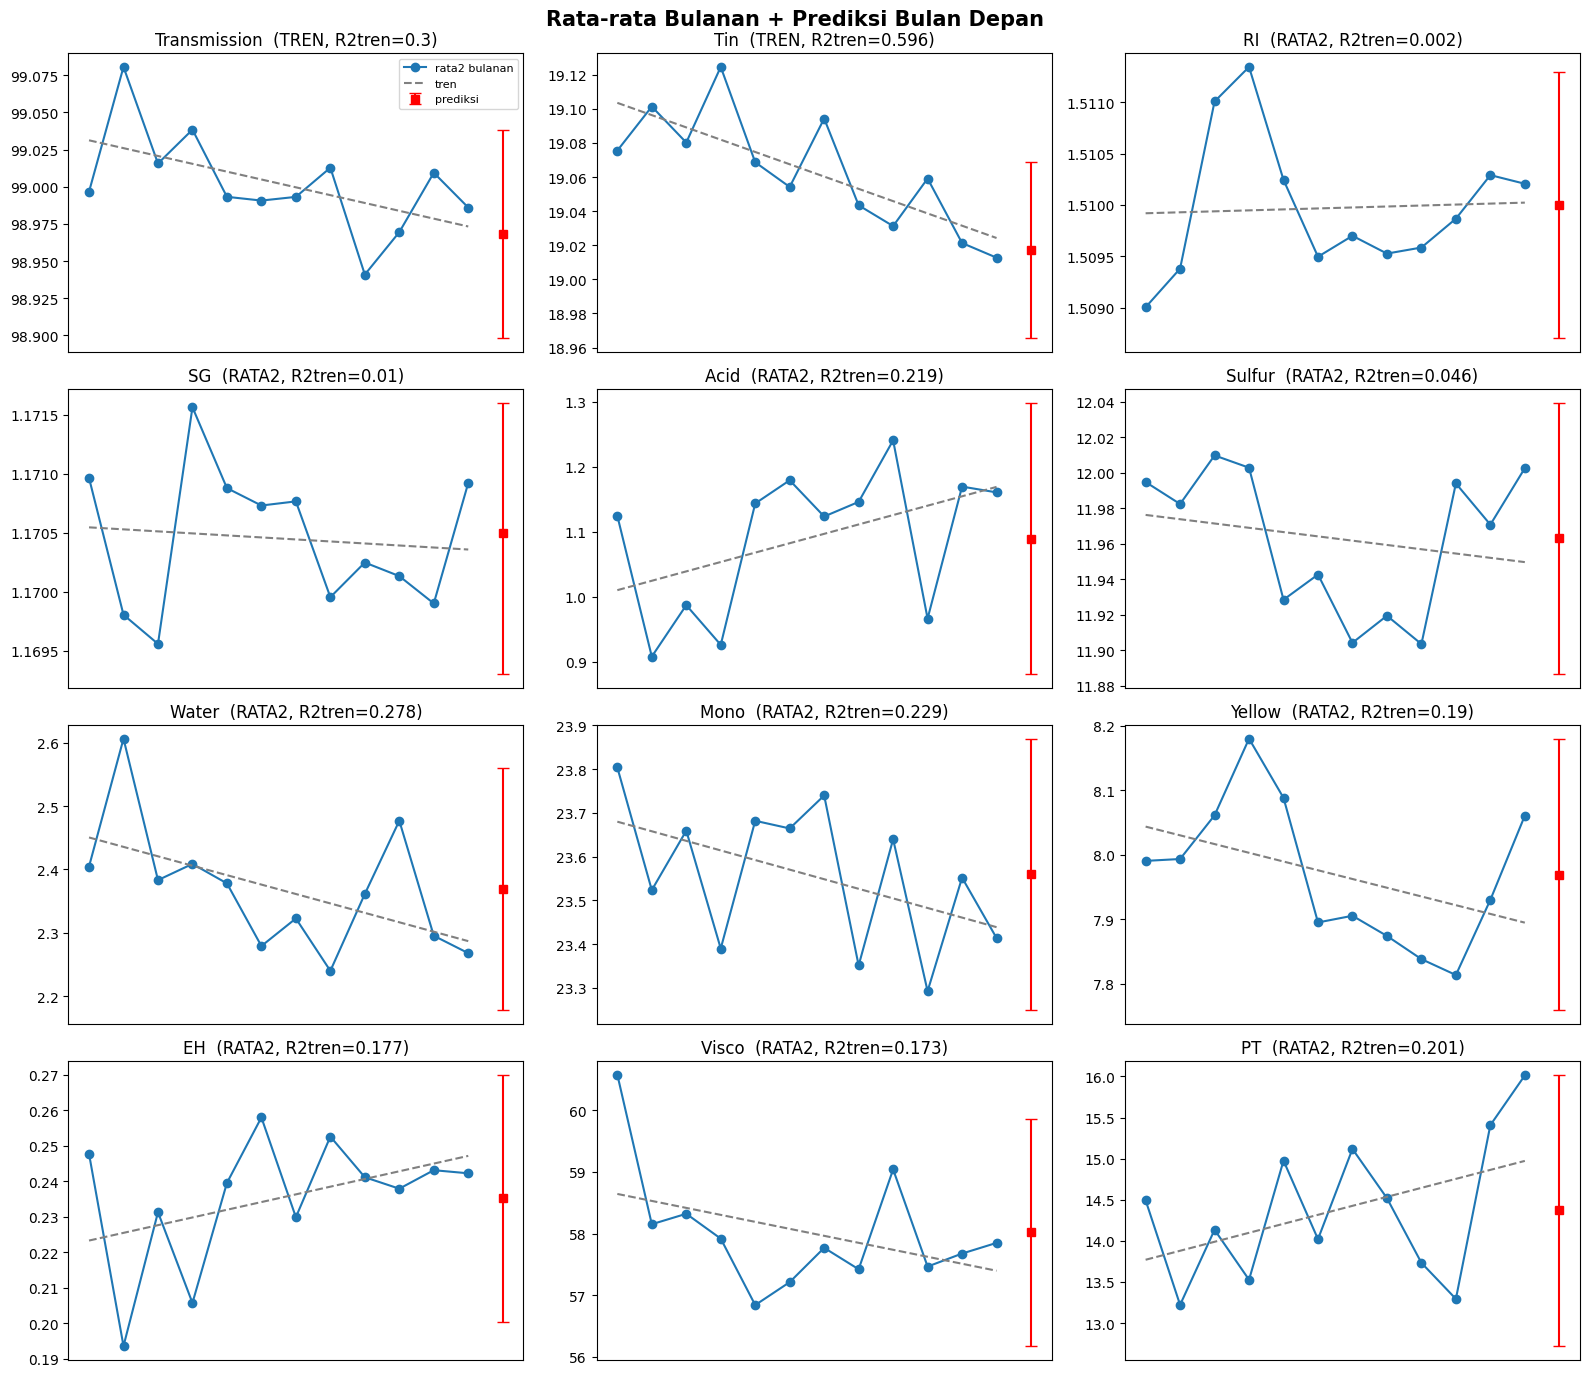

In [5]:
fig,axes=plt.subplots(4,3,figsize=(16,14))
x=np.arange(len(mon))
for ax,c in zip(axes.ravel(),param):
    y=mon[c].values
    ax.plot(range(len(mon)),y,'o-',label='rata2 bulanan')
    b=np.polyfit(x,y,1); ax.plot(x,np.polyval(b,x),'--',color='gray',label='tren')
    row=pred[pred.Parameter==c].iloc[0]
    ax.errorbar(len(mon),row.Prediksi,
                yerr=[[row.Prediksi-row.Batas_bawah95],[row.Batas_atas95-row.Prediksi]],
                fmt='s',color='red',capsize=4,label='prediksi')
    ax.set_title(f'{c}  ({row.Model}, R2tren={row.R2_tren})'); ax.set_xticks([])
axes.ravel()[0].legend(fontsize=8)
plt.suptitle('Rata-rata Bulanan + Prediksi Bulan Depan',fontsize=15,fontweight='bold')
plt.tight_layout(); plt.savefig('grafik_prediksi_bulanan.png',dpi=130); plt.show()

## 11. Tabel Ringkasan Komprehensif

Merangkum semua hasil analisis dalam satu tabel: prediksi, interval, metrik evaluasi,
normalitas, dan stasioneritas.

In [ ]:
# Gabungkan semua hasil ke satu tabel ringkasan
ringkasan = pred.copy()

# Merge evaluasi
ringkasan = ringkasan.merge(df_eval[['Parameter','MAE','RMSE','MAPE (%)']], on='Parameter', how='left')

# Merge cross-validation
ringkasan = ringkasan.merge(df_cv[['Parameter','CV-MAE (rata-rata)']], on='Parameter', how='left')

# Merge normalitas
ringkasan = ringkasan.merge(df_normal[['Parameter','p-value','Keterangan']].rename(
    columns={'p-value':'Shapiro p-val','Keterangan':'Normalitas'}), on='Parameter', how='left')

# Merge stasioneritas
ringkasan = ringkasan.merge(df_stasioner[['Parameter','p-value','Keterangan']].rename(
    columns={'p-value':'ADF p-val','Keterangan':'Stasioneritas'}), on='Parameter', how='left')

print(f"=== TABEL RINGKASAN KOMPREHENSIF — Prediksi Bulan: {bulan_depan} ===")
display(ringkasan)

# Simpan tabel ringkasan
ringkasan.to_csv('ringkasan_prediksi_lengkap.csv', index=False)
print("\nTersimpan: ringkasan_prediksi_lengkap.csv")

## 12. Kesimpulan

- **Tin** menunjukkan tren menurun yang cukup jelas (R²≈0.6) → prediksinya paling bermakna.
- Sebagian besar parameter lain **stabil/datar** → prediksi ≈ rata-rata historis ± interval
  (berguna sebagai **batas kendali mutu** bulan depan).
- **Validasi asumsi:**
  - Uji **Shapiro-Wilk** mengonfirmasi apakah distribusi data mendukung interval 95%.
  - Uji **ADF** mengonfirmasi parameter mana yang memiliki tren signifikan vs stasioner.
- **Evaluasi model:** Metrik MAE, RMSE, dan MAPE memberikan gambaran kuantitatif akurasi prediksi.
- **Cross-validation** memvalidasi bahwa model tidak overfit pada data historis.
- **Keterbatasan:** data hanya ~12 bulan, sehingga **pola musiman & prediksi tahunan belum bisa**
  dilakukan (butuh 2–3 tahun data).
- Tanggal adalah **variabel terbaik yang tersedia** untuk forecasting ini, namun ia hanya **proksi**
  dari penyebab sebenarnya (kondisi proses & bahan baku) yang belum tercatat.

## Daftar Referensi

### Jurnal Ilmiah
1. Shapiro, S. S., & Wilk, M. B. (1965). "An Analysis of Variance Test for Normality (Complete Samples)."
   *Biometrika*, 52(3/4), 591–611. [DOI: 10.2307/2333709](https://doi.org/10.2307/2333709)

2. Dickey, D. A., & Fuller, W. A. (1979). "Distribution of the Estimators for Autoregressive Time Series
   with a Unit Root." *Journal of the American Statistical Association*, 74(366), 427–431.
   [DOI: 10.2307/2286348](https://doi.org/10.2307/2286348)

3. Hyndman, R. J., & Koehler, A. B. (2006). "Another Look at Measures of Forecast Accuracy."
   *International Journal of Forecasting*, 22(4), 679–688.
   [DOI: 10.1016/j.ijforecast.2006.03.001](https://doi.org/10.1016/j.ijforecast.2006.03.001)

4. Bergmeir, C., & Benítez, J. M. (2012). "On the Use of Cross-validation for Time Series Predictor
   Evaluation." *Information Sciences*, 191, 192–213.
   [DOI: 10.1016/j.ins.2011.12.028](https://doi.org/10.1016/j.ins.2011.12.028)

### Buku
5. McKinney, W. (2017). *Python for Data Analysis*, 2nd Ed. O'Reilly.
   [Link](https://www.oreilly.com/library/view/python-for-data/9781491957653/)

6. Hyndman, R. J. & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice*, 3rd Ed. OTexts.
   [Baca Gratis Online](https://otexts.com/fpp3/)

### Dokumentasi Library
7. `pandas.DataFrame.describe` — [Link](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html)
8. `scipy.stats.shapiro` — [Link](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.shapiro.html)
9. `statsmodels.tsa.stattools.adfuller` — [Link](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.adfuller.html)
10. `sklearn.metrics` — [Link](https://scikit-learn.org/stable/modules/model_evaluation.html)
11. `sklearn.model_selection.TimeSeriesSplit` — [Link](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html)